In [94]:
from importlib import reload
# reload(simulation_functions)
import numpy as np
from matplotlib import pyplot as plt

In [95]:
from scipy.optimize import minimize

In [96]:
from jointlearn import simulation as simulation_functions

In [97]:
scenes, languages = simulation_functions.define_objects()

# Basic Bayesian learning 


In [5]:
# (interpretation function, word order, scene, agent x action x patient)
# contains the word that the language uses for each scene
languages.shape

(5040, 6, 36, 3)

In [6]:
5040*6

30240

Run single experiment:

In [8]:
n_trials = 50
n_participants = 6
noise_vector_uniform = np.linspace(0.2, 0.5, n_participants)
noise_vector_ignore = np.linspace(0.2, 0.95, n_participants)

In [7]:
print(noise_vector_ignore)
print(noise_vector_uniform)

[0.2  0.35 0.5  0.65 0.8  0.95]
[0.2  0.26 0.32 0.38 0.44 0.5 ]


In [ ]:
bayesian_results_noisefree = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='same', 
    simulate_responses=True,
    negative_evidence=False,
    noise=0,
    return_p_scene=True,
    noise_type='ignore',
    feedback_on_false_choices=True
)

IntProgress(value=0, max=6)

In [ ]:
bayesian_results_ignore = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='same', 
    simulate_responses=True,
    negative_evidence=False,
    noise=noise_vector_ignore,
    return_p_scene=True,
    noise_type='ignore',
    feedback_on_false_choices=True
)

IntProgress(value=0, max=6)

In [ ]:
bayesian_results_uniform = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='same', 
    simulate_responses=True,
    negative_evidence=False,
    noise=noise_vector_uniform,
    return_p_scene=True,
    noise_type='uniform',
    feedback_on_false_choices=True
)

IntProgress(value=0, max=6)

In [19]:
def minimize_for_cascade(true_probs):
    def p_max_prod(params):
        p_max, s, T = params
        trials = np.arange(len(true_probs))
        probs = np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)
        return np.sum((probs - true_probs)**2)
    return p_max_prod

def minimize_for_logistic(true_probs):
    def logistic_func(beta):
        trials = np.arange(len(true_probs))
        intercept = np.log(0.25 / (1 - 0.25))
        logistic_curve = 1 / (1 + np.exp(-(intercept + trials*beta)))
        return np.sum((logistic_curve - true_probs)**2)
    return logistic_func

def plot_bayesian_results(bayesian_results_dict, noise_vectors, save=False, pmax_for_true=None, x_max=None, pathadd=''):
    """
    pmax_for_true: ceiling probability of correct for the Bayesian model/approximation thereof
    """
    correct_fig, correct_axs = plt.subplots(
        len(bayesian_results_dict), 
        5, 
        figsize=(6, 3), sharex=True, sharey=True
    )

    probs_fig, probs_axs = plt.subplots(
        len(bayesian_results_dict), 
        5, 
        figsize=(6, 3), sharex=True, sharey=True
    )

    for j, ((noisetype, bayesian_results), noise_vector) in enumerate(zip(bayesian_results_dict.items(), noise_vectors)):

        hist_p_scenes = bayesian_results['history_p_scenes']
        n_trials, n_participants, _ = hist_p_scenes.shape

        history_states = bayesian_results['history_states']
        true_interpretation_func, true_word_order = bayesian_results['indices_true_language'].T
        
        probs_true_langs = history_states[
            :,
            np.arange(n_participants),
            true_interpretation_func, 
            true_word_order
        ]

        # probability of selecting the correct scene
        # given distribution over languages
        p_correct_scene = (
            hist_p_scenes[bayesian_results['true_scenes'][:,:,None] 
            == bayesian_results['indices_scenes_trials']]
            .reshape(n_trials,-1)
        )

        print('p_correct_scene.shape', p_correct_scene.shape)

        axrow_correct = correct_axs[j]
        axrow_probs = probs_axs[j]

        for i, (ax_correct,ax_probs,x,y,noise) in enumerate(zip(
            axrow_correct, axrow_probs, p_correct_scene.T, probs_true_langs.T, noise_vector)):
            
            if pmax_for_true is not None:
                x = np.minimum(x, pmax_for_true)

            result = minimize(
                minimize_for_cascade(x), 
                x0=[0.8, 0.5, 10],
                bounds=[(0,1), (1,None), (0, len(x))]
            )

            def p_max_prod(params):
                p_max, s, T = params
                trials = np.arange(len(x))
                return np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)
            
            def logistic_func(beta):
                trials = np.arange(len(x))
                intercept = np.log(0.25 / (1 - 0.25))
                return 1 / (1 + np.exp(-(intercept + trials*beta)))

            result_logistic = minimize(
                minimize_for_logistic(x), 
                x0=[0.8],
                # bounds=[]
            )

            ax_correct.plot(x, color='gray', label='true probability')
            ax_probs.plot(y, color='gray')

            # probabilities right choice with maximum likelihood parameters
            probs_choices = p_max_prod(result.x)
            ax_correct.plot(probs_choices, color='red', alpha=1.0, lw=0.5, ls='--', label='cascade model')
            probs_choices_logistic = logistic_func(result_logistic.x)
            ax_correct.plot(probs_choices_logistic, color='blue', alpha=1.0, lw=0.5, ls='--', label='logistic model')

            if i == 0:
                ax_correct.set_ylabel(noisetype)
                ax_probs.set_ylabel(noisetype)

            ax_correct.text(0.5, 0.1, f'$\\epsilon=${noise:.2f}', ha='center', va='center', transform=ax_correct.transAxes)
            ax_probs.text(0.5, 0.1, f'$\\epsilon=${noise:.2f}', ha='center', va='center', transform=ax_probs.transAxes)

    # put a title along the y axis
    correct_axs[1,0].set_title('Probability of correct scene', rotation='vertical', x=-0.8, y=0.4, va='center')
    correct_axs[-1,2].set_xlabel('Trial')
    correct_axs[0,0].set_ylim(0,1.1)
    if x_max is not None:
        correct_axs[0,0].set_xlim(0, x_max)
    
    correct_axs[0,0].legend(bbox_to_anchor=(1.5, 1.1), framealpha=1)

    # add space at the bottom of the figure
    correct_fig.subplots_adjust(bottom=0.15)

    probs_axs[1,0].set_title('Probability of true language', rotation='vertical', x=-0.8, y=0.4, va='center')
    probs_axs[-1,0].set_xlabel('Trial')
    if x_max is not None:
        probs_axs[0,0].set_xlim(0, x_max)
    probs_fig.subplots_adjust(bottom=0.15)

    # clear the top right two axes, including content
    for ax in correct_axs[0, 1:]:
        ax.clear()
        ax.axis('off')

    # probs_axs[-1, -1].axis('off')

    if save:
        correct_fig.savefig(f'./figures/p_correct_scene_{pathadd}.png', dpi=300)
        probs_fig.savefig(f'./figures/probs_true_lang_{pathadd}.png', dpi=300)


p_correct_scene.shape (50, 6)
p_correct_scene.shape (50, 6)


/tmp/ipykernel_11503/4014342229.py:5: RuntimeWarning: divide by zero encountered in divide
  probs = np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)
/tmp/ipykernel_11503/4014342229.py:5: RuntimeWarning: invalid value encountered in divide
  probs = np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)
/tmp/ipykernel_11503/4014342229.py:5: RuntimeWarning: overflow encountered in power
  probs = np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)
/tmp/ipykernel_11503/4014342229.py:76: RuntimeWarning: overflow encountered in power
  return np.where(trials < T, 0.25 + (p_max - 0.25) * ( trials / T )**s, p_max)


p_correct_scene.shape (50, 6)


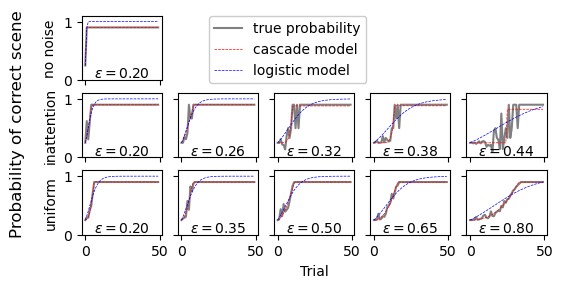

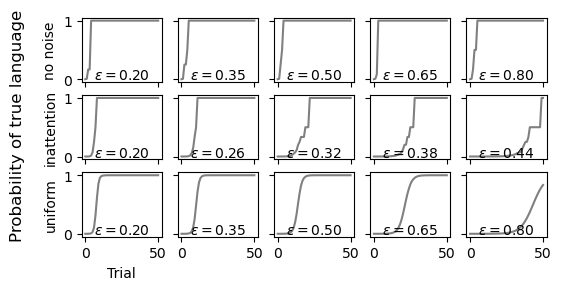

In [23]:
plot_bayesian_results(
    {
        'no noise': bayesian_results_noisefree,
        'inattention': bayesian_results_ignore,
        'uniform': bayesian_results_uniform,
    },
    noise_vectors=[noise_vector_ignore, noise_vector_uniform, noise_vector_ignore],
    # x_max=30,
    pmax_for_true=0.9,
    save=False,
    pathadd='ceiling=0.9'
)

# Particle approximation

In [19]:
reload(simulation_functions)

<module 'scripts.simulation_functions' from '/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/simulation_functions.py'>

In [25]:
n_participants = 20
n_trials = 50
n_particles_vector = np.linspace(1000, 10000, n_participants).astype(int)


In [26]:
bayesian_results_ignore_marginalize = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=False,
    noise=None,
    return_p_scene=True,
    noise_type='particles',
    return_p_correct=True,
    n_eval_trials=1000,
    n_particles=n_particles_vector
)

IntProgress(value=0, max=20)

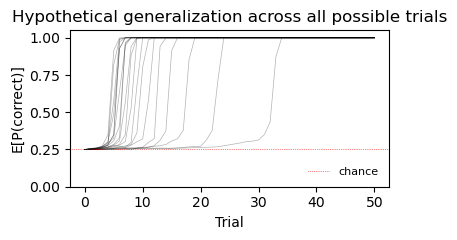

In [27]:
# Hypothetical P(correct) across all possible trials, estimated from
# n_eval_trials hypothetical trials per state in history_states.
# Shape: (n_trials+1, n_participants) — index 0 is the prior.
history_p_correct = bayesian_results_ignore_marginalize['history_p_correct']
p_correct_eval_mean = history_p_correct.mean(axis=1)

fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(history_p_correct, color='black', alpha=0.3, linewidth=0.5)
ax.axhline(0.25, color='red', linestyle=':', linewidth=0.5, label='chance')

ax.set_xlabel('Trial')
ax.set_ylabel('E[P(correct)]')
ax.set_title('Hypothetical generalization across all possible trials')
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

Now same thing, but the number of particles is taken from a negative binomial distribution on each trial, so there's more variation across trials:

In [53]:
n_participants = 3
n_trials = 50
n_particles_vector =  n_particles=[(2000, 2), (2000, 2), (2000, 2)]


In [54]:
bayesian_results_ignore_marginalize = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=False,
    noise=None,
    return_p_scene=True,
    noise_type='particles_negbin',
    return_p_correct=True,
    n_eval_trials=1000,
    n_particles=n_particles_vector
)

IntProgress(value=0, max=3)

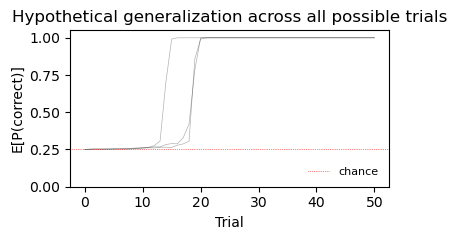

In [55]:
# Hypothetical P(correct) across all possible trials, estimated from
# n_eval_trials hypothetical trials per state in history_states.
# Shape: (n_trials+1, n_participants) — index 0 is the prior.
history_p_correct = bayesian_results_ignore_marginalize['history_p_correct']
p_correct_eval_mean = history_p_correct.mean(axis=1)

fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(history_p_correct, color='black', alpha=0.3, linewidth=0.5)
ax.axhline(0.25, color='red', linestyle=':', linewidth=0.5, label='chance')

ax.set_xlabel('Trial')
ax.set_ylabel('E[P(correct)]')
ax.set_title('Hypothetical generalization across all possible trials')
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [38]:
reload(simulation_functions)

<module 'scripts.simulation_functions' from '/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/simulation_functions.py'>

In [98]:
# Prior over word orders from crosslinguistic frequencies, paired with
# a uniform prior over the 5040 interpretation functions.
#
# define_objects builds word_orders as permutations of (S=0, V=1, O=2)
# in itertools.permutations order, i.e. (SVO, SOV, VSO, VOS, OSV, OVS).
wo_counts = np.array([435, 497, 85, 26, 4, 9], dtype=float)
wo_labels = ['SVO', 'SOV', 'VSO', 'VOS', 'OSV', 'OVS']

word_order_prior_xling = wo_counts / wo_counts.sum()
interpret_prior_uniform = np.ones(5040) / 5040

print('Crosslinguistic word-order prior:')
for label, p in zip(wo_labels, word_order_prior_xling):
    print(f'  {label}: {p:.3f}')

Crosslinguistic word-order prior:
  SVO: 0.412
  SOV: 0.471
  VSO: 0.080
  VOS: 0.025
  OSV: 0.004
  OVS: 0.009


In [99]:
n_particles_values = np.linspace(100, 10000, 10).astype(int)
n_orders = 6
samples_per_cell = 1   # participants per (word_order, n_particles) cell of the grid
n_trials = 50

per_order = samples_per_cell * len(n_particles_values)   # 10 participants per word order
n_participants = n_orders * per_order                     # 60 in total

# Word orders assigned in blocks (true_languages_setting='balanced'):
# participants 0..per_order-1 are order 0, the next block is order 1, etc.
# Inside each order block we cycle through the n_particles values, so every
# (word_order, n_particles) cell gets `samples_per_cell` runs.
n_particles_vector = np.tile(n_particles_values, n_orders * samples_per_cell)

bayesian_results_xling_prior = simulation_functions.simulate_full_experiment(
    n_trials=n_trials,
    n_participants=n_participants,
    true_languages_setting='balanced',
    simulate_responses=True,
    negative_evidence=False,
    noise=None,
    return_p_scene=True,
    noise_type='particles',
    return_p_correct=True,
    n_eval_trials=1000,
    n_particles=n_particles_vector,
    interpret_prior=interpret_prior_uniform,
    word_order_prior=word_order_prior_xling,
)

history_p_correct = bayesian_results_xling_prior['history_p_correct']
true_word_orders = bayesian_results_xling_prior['indices_true_language'][:, 1]

IntProgress(value=0, max=60)

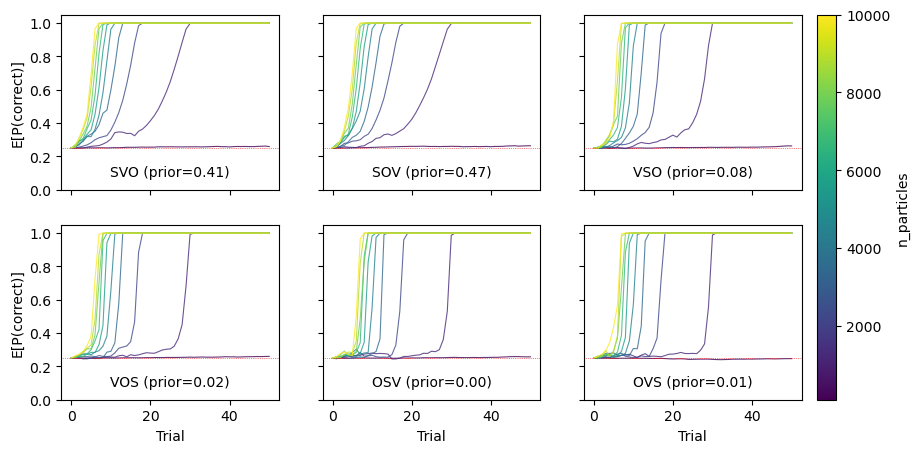

In [100]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey=True)
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=n_particles_values.min(), vmax=n_particles_values.max())

for wo_idx in range(6):
    ax = axes[wo_idx // 3, wo_idx % 3]
    mask = true_word_orders == wo_idx
    for i in np.where(mask)[0]:
        ax.plot(
            history_p_correct[:, i],
            color=cmap(norm(n_particles_vector[i])),
            alpha=0.8, linewidth=0.8,
        )
    ax.axhline(0.25, color='red', linestyle=':', linewidth=0.5)
    ax.text(
        0.5, 
        0.1, 
        f'{wo_labels[wo_idx]} (prior={word_order_prior_xling[wo_idx]:.2f})', 
        ha='center', 
        va='center', 
        transform=ax.transAxes
    )
    ax.set_ylim(0, 1.05)

for ax in axes[-1, :]:
    ax.set_xlabel('Trial')
for ax in axes[:, 0]:
    ax.set_ylabel('E[P(correct)]')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes.ravel().tolist(), label='n_particles',
             orientation='vertical', fraction=0.025, pad=0.02)

# fig.suptitle('Particles + crosslinguistic word-order prior, by true word order')
plt.show()

Now plot assuming that some word orders will never be considered.

In [89]:
reload(simulation_functions)

<module 'scripts.simulation_functions' from '/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/simulation_functions.py'>

In [90]:
word_order_prior_xling = np.array([0.5, 0.5, 0, 0, 0, 0])
interpret_prior_uniform = np.ones(5040) / 5040

bayesian_results_xling_prior = simulation_functions.simulate_full_experiment(
    n_trials=n_trials,
    n_participants=n_participants,
    true_languages_setting='balanced',
    simulate_responses=True,
    negative_evidence=False,
    noise=None,
    return_p_scene=True,
    noise_type='particles',
    return_p_correct=True,
    n_eval_trials=1000,
    n_particles=n_particles_vector,
    interpret_prior=interpret_prior_uniform,
    word_order_prior=word_order_prior_xling,
)

history_p_correct = bayesian_results_xling_prior['history_p_correct']
true_word_orders = bayesian_results_xling_prior['indices_true_language'][:, 1]

IntProgress(value=0, max=60)

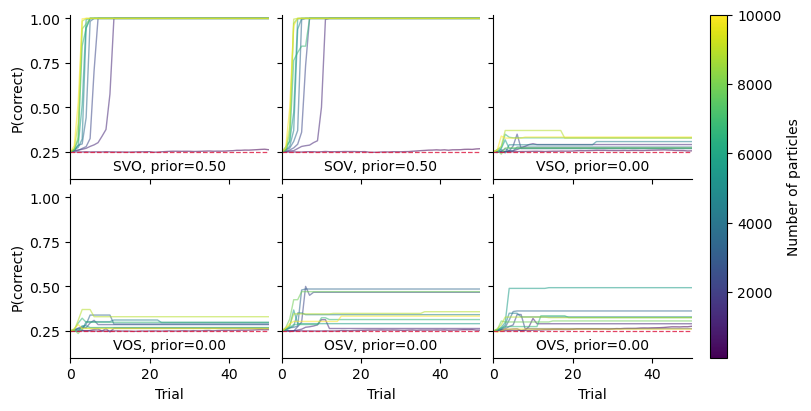

In [91]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(8.0, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=n_particles_values.min(), vmax=n_particles_values.max())

for wo_idx, ax in enumerate(axes.flat):
    mask = true_word_orders == wo_idx
    idxs = np.where(mask)[0]

    # Optional: draw in color order for a smoother visual gradient
    idxs = idxs[np.argsort(n_particles_vector[idxs])]

    for i in idxs:
        ax.plot(
            history_p_correct[:, i],
            color=cmap(norm(n_particles_vector[i])),
            alpha=0.55,
            linewidth=1.0,
        )

    ax.axhline(0.25, color="crimson", linestyle="--", linewidth=0.9, alpha=0.8)
    ax.text(
        0.5, 
        0.075, 
        f"{wo_labels[wo_idx]}, prior={word_order_prior_xling[wo_idx]:.2f}",
        ha='center', 
        va='center', 
        transform=ax.transAxes,
        fontsize=10,
    )
    ax.set_ylim(0.1, 1.02)
    ax.set_xlim(0, history_p_correct.shape[0] - 1)
    ax.set_yticks(np.linspace(0.25, 1, 4))
    # ax.grid(True, axis="y", color="0.9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[-1, :]:
    ax.set_xlabel("Trial")
for ax in axes[:, 0]:
    ax.set_ylabel("P(correct)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    fraction=0.035,
    pad=0.03,
)
cbar.set_label("Number of particles")

plt.savefig(
    "figures/word_order_zero_prior.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05,
)
plt.show()

# Specific language

In [ ]:
index_true_language = (2,3)

scenes, languages, language_interpret, word_orders = simulation_functions.define_objects(
    full_output=True
)

word_order_prior, interpret_prior = simulation_functions.define_priors(
    word_orders, 
    language_interpret
)

trials = simulation_functions.generate_trials(
    languages[index_true_language], 
    10, 
    scenes, 
    4
)

history, _ = simulation_functions.run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=True
)

In [ ]:
[h[index_true_language] for h in history]

[3.3068783068783064e-05,
 0.006944444444444444,
 0.16666666666666666,
 0.5,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

# Run multiple experiments:

1. Considering negative evidence (i.e., not updating when they get it wrong)

In [ ]:
index_true_language = (2,3)

histories = simulation_functions.run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=True
)

true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

In [ ]:
np.array(histories).shape

(100, 11, 5040, 6)

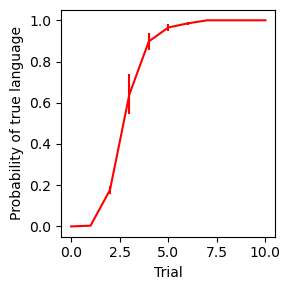

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
# ax.plot(
#     np.array(true_hists).T,
#     color='black',
#     alpha=0.05
# )
ax.errorbar(
    np.arange(len(means)), 
    means, 
    variances,
    color='red'
)
ax.set_xlabel('Trial')
ax.set_ylabel('Probability of true language')
plt.tight_layout()
fig.savefig('figures/perfectBayesian.png', dpi=300)

2. Without considering negative evidence

IntProgress(value=0)

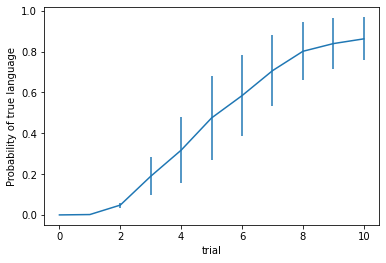

In [ ]:
index_true_language = (2,3)

histories = simulation_functions.run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=False
)

true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()